2. Location analysis: Analyze the location data associated with tweets to understand where particular location are most prevalent.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('CSV/location.csv')
df.head(2)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8


In [14]:
location_counts = df['Country'].value_counts()
print(location_counts)

Country
USA               59
USA               55
UK                49
Canada            44
Australia         41
                  ..
Netherlands        1
USA                1
Germany            1
France             1
USA                1
Name: count, Length: 115, dtype: int64


In [20]:
top_locations = location_counts.head(10)
print(top_locations)
top_location_names = top_locations.index.tolist()
df_top = df[df['Country'].isin(top_location_names)]

Country
USA               59
USA               55
UK                49
Canada            44
Australia         41
Canada            34
UK                33
India             21
USA               20
Canada            17
Name: count, dtype: int64


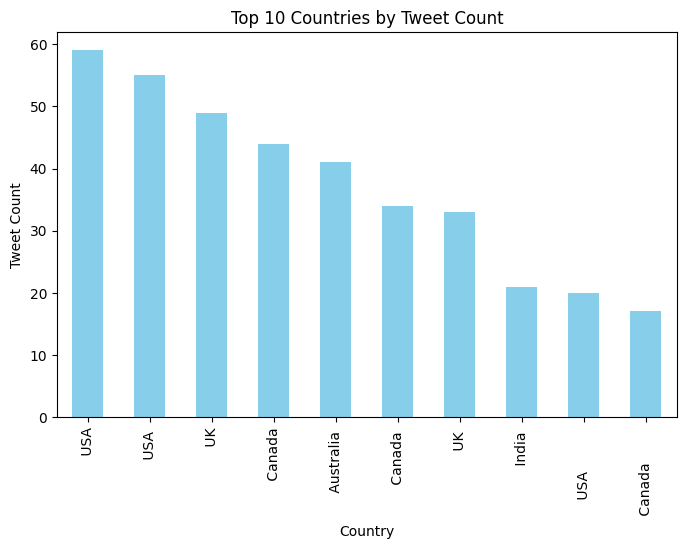

In [27]:
top_locations.plot(kind='bar', figsize=(8, 5), color='skyblue')
plt.title("Top 10 Countries by Tweet Count")
plt.xlabel("Country")
plt.ylabel("Tweet Count")
plt.show()

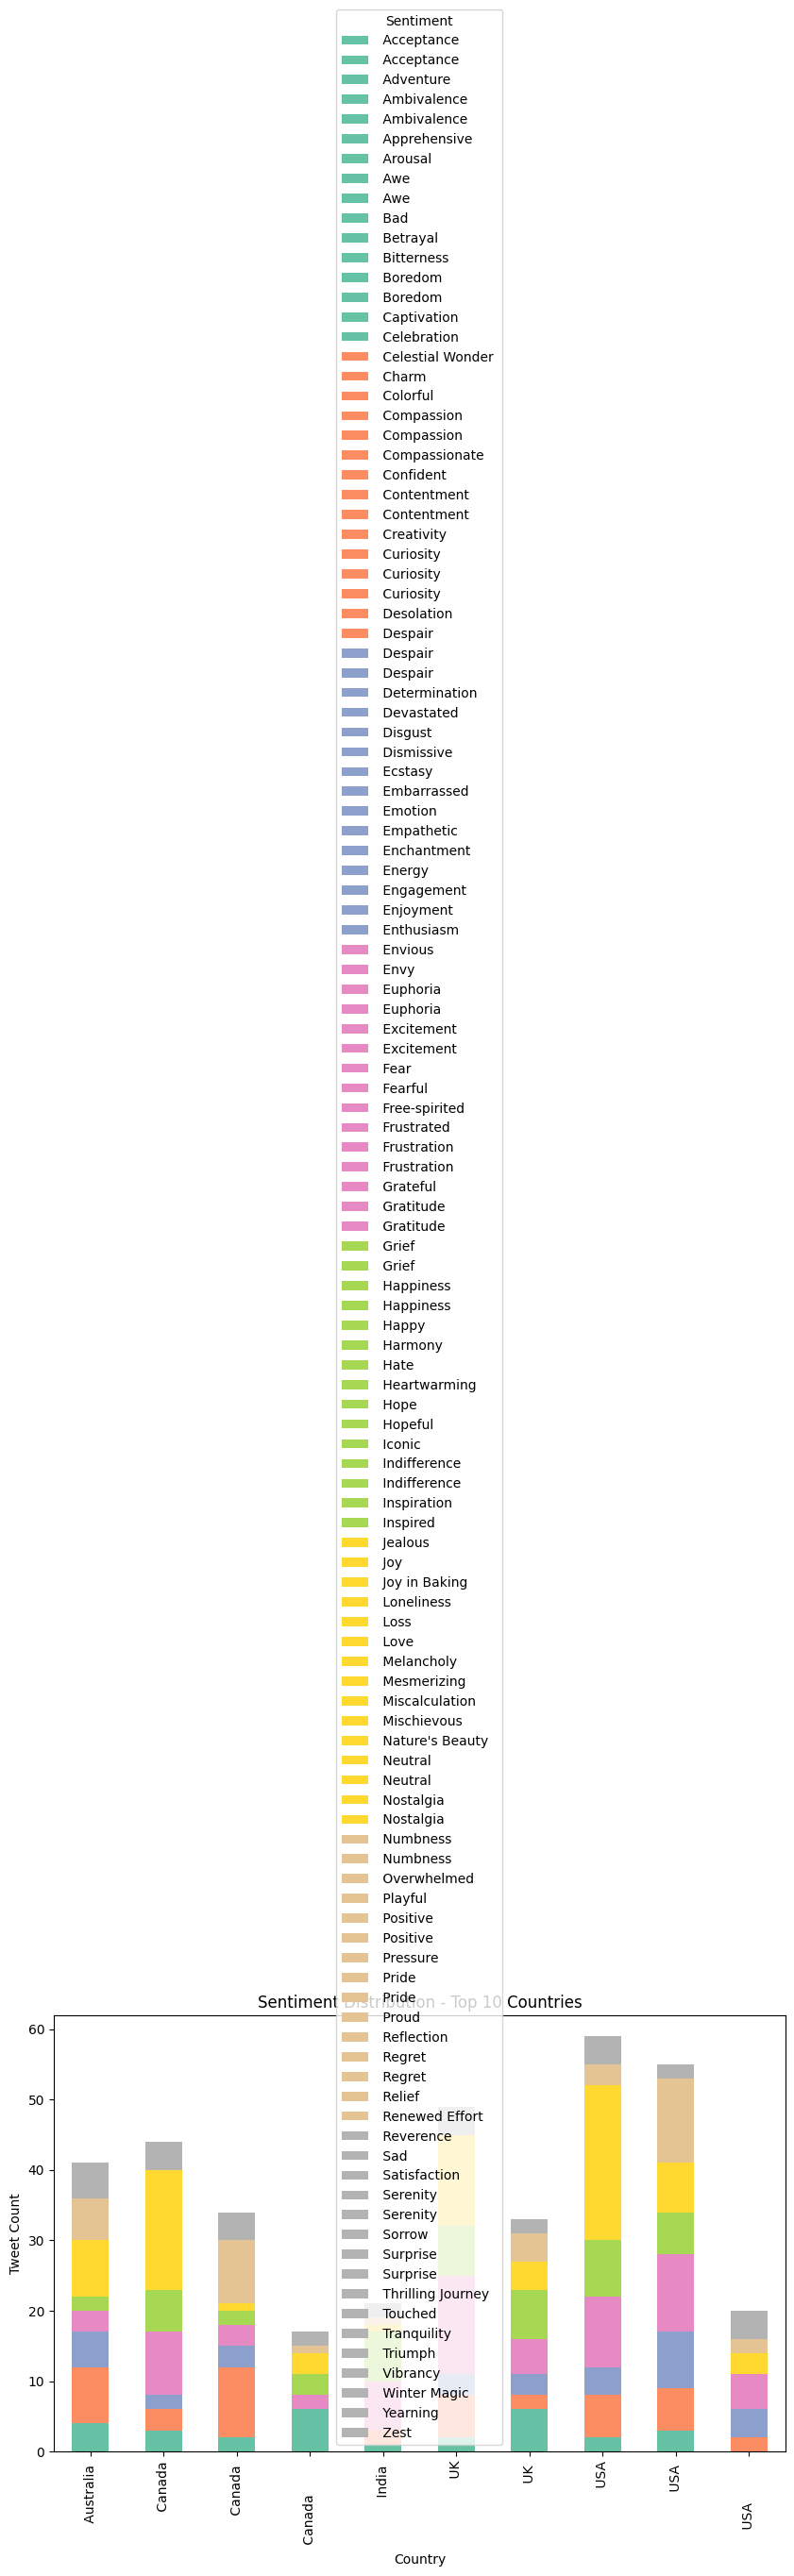

In [26]:
sentiment_top = df_top.groupby(['Country', 'Sentiment']).size().unstack().fillna(0)

sentiment_top.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title("Sentiment Distribution - Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Tweet Count")
plt.show()


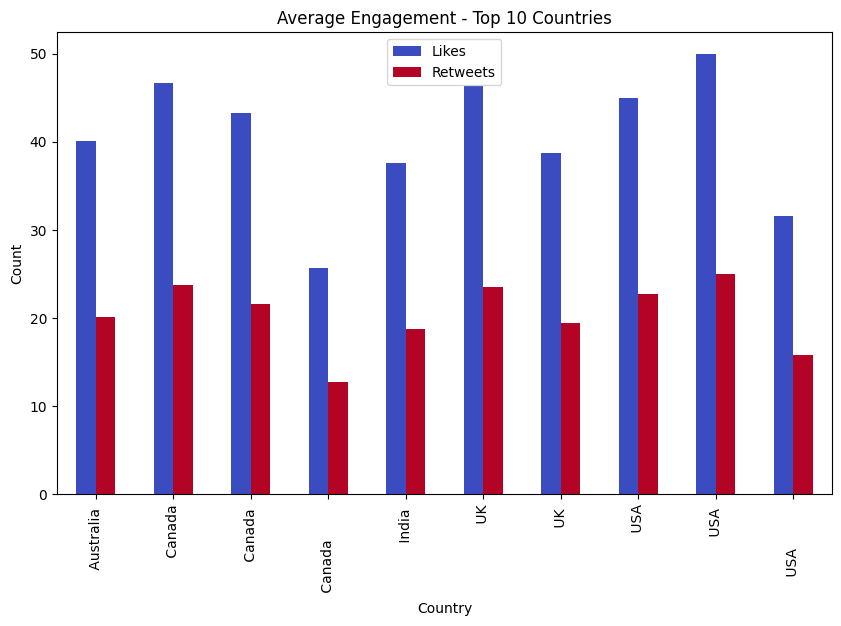

In [25]:
engagement_top = df_top.groupby('Country')[['Likes', 'Retweets']].mean()

engagement_top.plot(kind='bar', figsize=(10,6), colormap='coolwarm')
plt.title("Average Engagement - Top 10 Countries")
plt.ylabel("Count")
plt.show()


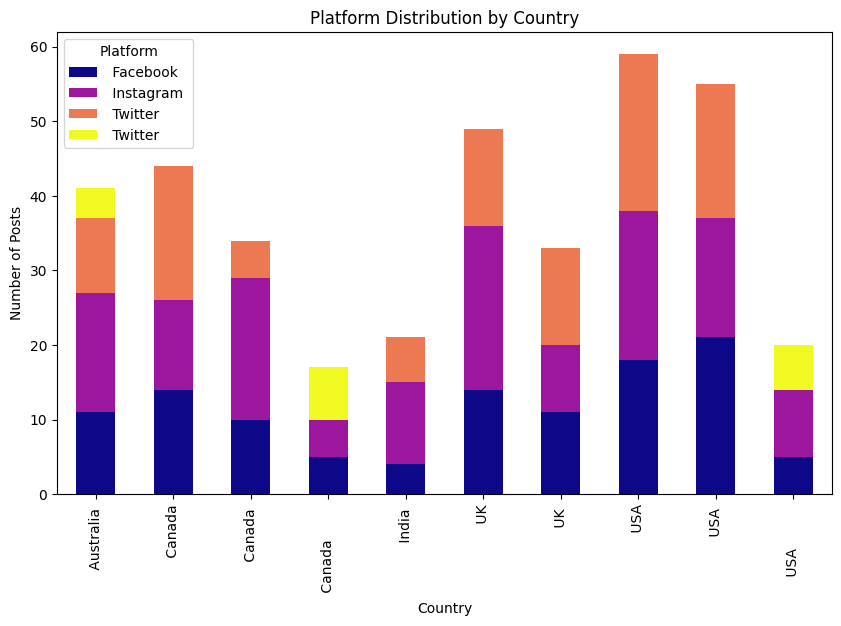

In [24]:
platform_country = df_top.groupby(['Country', 'Platform']).size().unstack().fillna(0)
platform_country.plot(kind='bar', stacked=True, figsize=(10,6), colormap='plasma')
plt.title("Platform Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Posts")
plt.show()
